In [165]:
import pandas as pd
import numpy as np
from pathlib import Path
from config import get_engine

In [166]:
OUTPUT_DIR = Path('output')
DATA_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)
engine = get_engine()

In [167]:
df=pd.read_csv(OUTPUT_DIR / 'master_dataset1.csv')

In [168]:
df.head()

,Customer_ID,Geo_ID,Industry_ID,Product_ID,Cluster_Label,Account_Tier,Company_Size,Company_Age_Years,Employees,Legal_Entity_Type,...,Module,Base_Monthly_Price_USD,Included_Licenses,API_Limit_Monthly,SLA_Uptime_Pct,Support_Level,AI_Features_Included,avg_monthly_revenue,revenue_per_employee,licenses_unused
0,11177,121,4,27,At-Risk SMB,Platinum,Startup (<50),10,91.0,Ltd,...,Platform,4000,500,500000,99.9,Premium,Yes,8.652174,1.450549,6
1,14771,44,5,25,High-Growth Startup,Gold,Startup (<50),1,309.0,AG,...,Platform,500,25,10000,99.0,Community,No,356.750000,127.113269,107
2,11091,6,7,27,High Revenue Loyal,Bronze,Mid-Market (251-1000),7,990.0,GmbH,...,Platform,4000,500,500000,99.9,Premium,Yes,1623.492063,69.527273,-59
3,14818,1,3,17,At-Risk SMB,Strategic,Startup (<50),2,121.0,LLC,...,Analytics,500,25,10000,99.0,Community,No,28.772727,75.181818,-11
4,14376,19,10,18,High Revenue Loyal,Bronze,SMB (50-250),9,245.0,Sdn Bhd,...,Analytics,1500,100,100000,99.5,Standard,No,168.640000,57.318367,33


In [169]:
df.shape

(5272, 108)

In [170]:
df.duplicated().sum()

np.int64(158)

In [171]:
df.drop_duplicates(inplace=True)

In [172]:
df.info

<bound method DataFrame.info of       Customer_ID  Geo_ID  Industry_ID  Product_ID          Cluster_Label  \
0           11177     121            4          27            At-Risk SMB   
1           14771      44            5          25    High-Growth Startup   
2           11091       6            7          27     High Revenue Loyal   
3           14818       1            3          17            At-Risk SMB   
4           14376      19           10          18     High Revenue Loyal   
...           ...     ...          ...         ...                    ...   
5251        10475     120            5          14     High Revenue Loyal   
5254        14118      89           15          30  Discount-Heavy Stable   
5257        11185      19            8           1     High Revenue Loyal   
5264        12920      49           20          24    High-Growth Startup   
5270        13773     123           12          19    High-Growth Startup   

     Account_Tier           Company_Size  C

In [173]:
df.describe()

,Customer_ID,Geo_ID,Industry_ID,Product_ID,Company_Age_Years,Employees,Tenure_Months,Renewal_Probability,Health_Score,Last_Training_Days_Ago,...,GDP_Per_Capita_USD,Country_Weight,Weight,Base_Monthly_Price_USD,Included_Licenses,API_Limit_Monthly,SLA_Uptime_Pct,avg_monthly_revenue,revenue_per_employee,licenses_unused
count,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,4886.000000,5114.000000,5114.000000,5114.000000,5114.000000,...,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5.114000e+03,5114.000000,5114.000000,4886.000000,5114.000000
mean,12503.557098,75.270434,9.019163,16.288424,7.545366,743.845068,35.092687,0.720223,63.584865,84.946031,...,38034.356668,5.452483,5.320493,3056.609308,496.578021,4.936332e+05,99.598635,2192.732576,101.414435,11.293117
std,1443.607654,54.749225,6.277751,9.110848,4.158176,1365.478174,22.631402,0.200919,21.071919,110.531956,...,26834.838354,5.217112,2.957278,2472.293630,664.839868,6.669524e+05,0.353276,6200.248409,210.446672,41.729179
min,10001.000000,1.000000,1.000000,1.000000,1.000000,5.000000,3.000000,0.160000,0.000000,0.000000,...,1600.000000,1.000000,2.000000,500.000000,25.000000,1.000000e+04,99.000000,-2052.666667,0.000000,-175.000000
25%,11254.250000,25.000000,4.000000,9.000000,4.000000,104.000000,17.000000,0.570000,48.000000,17.000000,...,11000.000000,2.000000,3.000000,1500.000000,100.000000,1.000000e+05,99.500000,45.833333,3.308346,-15.000000
50%,12505.500000,64.000000,8.000000,16.000000,7.000000,293.000000,32.000000,0.740000,67.000000,45.000000,...,43000.000000,4.000000,4.000000,1500.000000,100.000000,1.000000e+05,99.500000,444.509356,29.232371,13.000000
75%,13755.750000,128.000000,14.000000,24.000000,10.000000,814.500000,52.000000,0.890000,80.000000,107.000000,...,57000.000000,6.000000,7.000000,4000.000000,500.000000,5.000000e+05,99.900000,1808.610000,105.191710,38.000000
max,15000.000000,178.000000,22.000000,32.000000,26.000000,18292.000000,108.000000,0.990000,100.000000,730.000000,...,90000.000000,18.000000,12.000000,8000.000000,2000.000000,2.000000e+06,99.990000,124806.333333,2850.000000,162.000000


In [174]:
df.isna().sum()[df.isna().sum()>0]

Company_Size             212
Employees                228
Contract_Type            211
CSM_Name                1547
CSAT_Score               205
NPS_Score                222
Score                    826
Resolution_Days          312
City                     353
Currency                 247
revenue_per_employee     228
dtype: int64

In [175]:
df['Company_Size'].value_counts()

Company_Size
Mid-Market (251-1000)    1456
SMB (50-250)             1351
Enterprise (1000+)       1094
Startup (<50)            1001
Name: count, dtype: int64

In [176]:
df[['Company_Size', 'Employees']]

,Company_Size,Employees
0,Startup (<50),91.0
1,Startup (<50),309.0
2,Mid-Market (251-1000),990.0
3,Startup (<50),121.0
4,SMB (50-250),245.0
...,...,...
5251,NaN,4087.0
5254,Mid-Market (251-1000),1511.0
5257,Mid-Market (251-1000),663.0
5264,Startup (<50),48.0


<Axes: xlabel='Company_Size'>

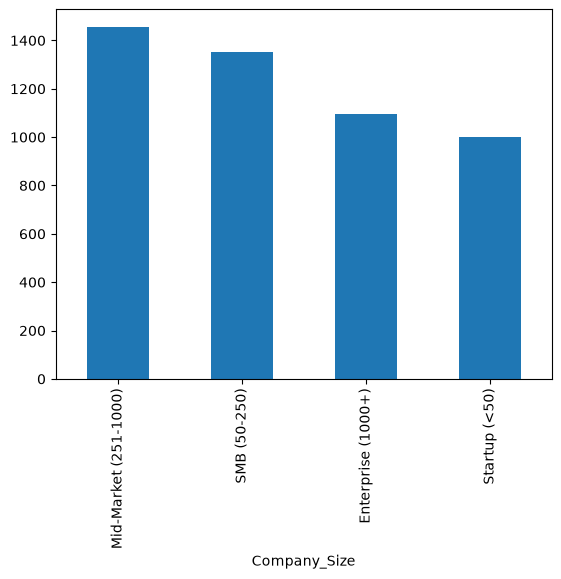

In [177]:
df['Company_Size'].value_counts().plot(kind='bar')


In [178]:
mask = df['Company_Size'].isna()

df.loc[mask & (df['Employees'] < 50), 'Company_Size'] = 'Startup (<50)'

df.loc[mask & (df['Employees'] >= 50) & (df['Employees'] <= 250),
    'Company_Size'
] = 'SMB (50-250)'

df.loc[
    mask & (df['Employees'] >= 251) & (df['Employees'] <= 1000),
    'Company_Size'
] = 'Mid-Market (251-1000)'

df.loc[
    mask & (df['Employees'] > 1000),
    'Company_Size'
] = 'Enterprise (1000+)'

<Axes: xlabel='Company_Size'>

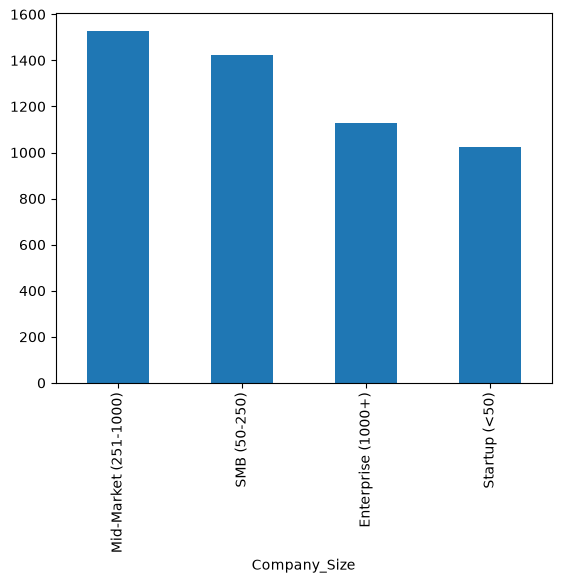

In [179]:
df['Company_Size'].value_counts().plot(kind='bar')

In [180]:
df['Company_Size']=df['Company_Size'].fillna(df['Company_Size'].mode()[0])

<Axes: xlabel='Company_Size'>

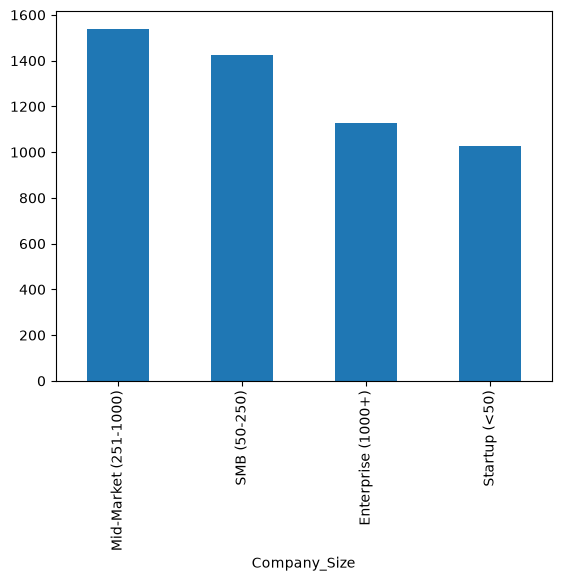

In [181]:
df['Company_Size'].value_counts().plot(kind='bar')


In [182]:
df.isna().sum()[df.isna().sum()>0]

Employees                228
Contract_Type            211
CSM_Name                1547
CSAT_Score               205
NPS_Score                222
Score                    826
Resolution_Days          312
City                     353
Currency                 247
revenue_per_employee     228
dtype: int64

In [183]:
df['Employees']

0         91.0
1        309.0
2        990.0
3        121.0
4        245.0
         ...  
5251    4087.0
5254    1511.0
5257     663.0
5264      48.0
5270     218.0
Name: Employees, Length: 5114, dtype: float64

<Axes: ylabel='Frequency'>

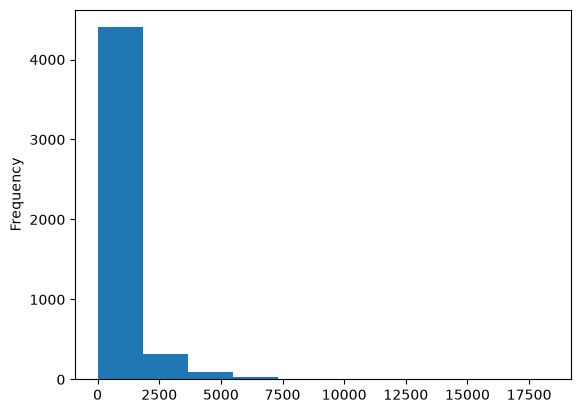

In [184]:
df['Employees'].plot(kind='hist')

In [185]:
df['Employees'].median()

np.float64(293.0)

In [186]:
df['Employees'] = df['Employees'].fillna(df['Employees'].median())

<Axes: ylabel='Frequency'>

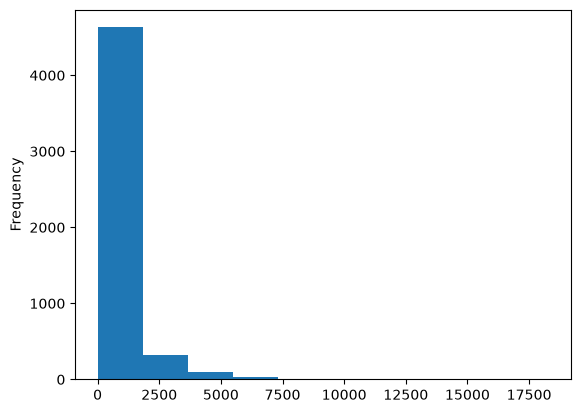

In [187]:
df['Employees'].plot(kind='hist')

In [188]:
df.isna().sum()[df.isna().sum()>0]

Contract_Type            211
CSM_Name                1547
CSAT_Score               205
NPS_Score                222
Score                    826
Resolution_Days          312
City                     353
Currency                 247
revenue_per_employee     228
dtype: int64

In [189]:
df['Contract_Start_Date'] = pd.to_datetime(df['Contract_Start_Date'])
df['Contract_End_Date'] = pd.to_datetime(df['Contract_End_Date'])

df['Total_days'] = (
    df['Contract_End_Date'] - df['Contract_Start_Date']
).dt.days

In [190]:
df[df['Contract_Type'].isna()][['Contract_Start_Date', 'Contract_End_Date', 'Contract_Type', 'Total_days']]

,Contract_Start_Date,Contract_End_Date,Contract_Type,Total_days
82,2024-10-24,2025-10-24,NaN,365
126,2023-10-30,2024-10-29,NaN,365
159,2023-10-26,2024-10-25,NaN,365
198,2024-02-16,2025-02-15,NaN,365
202,2024-12-26,2025-03-26,NaN,90
...,...,...,...,...
5144,2024-10-09,2026-10-09,NaN,730
5151,2023-09-25,2024-09-24,NaN,365
5152,2022-07-23,2022-10-21,NaN,90
5158,2024-04-26,2025-04-26,NaN,365


In [191]:
mask = df['Contract_Type'].isna()

df.loc[mask & (df['Total_days'] > 720), 'Contract_Type'] = 'Multi-Year'
df.loc[mask & (df['Total_days'] > 365) & (
    df['Total_days'] <= 720), 'Contract_Type'] = 'Annual'
df.loc[mask & (df['Total_days'] <= 365), 'Contract_Type'] = 'Monthly'

In [192]:
df.isna().sum()[df.isna().sum() > 0]

CSM_Name                1547
CSAT_Score               205
NPS_Score                222
Score                    826
Resolution_Days          312
City                     353
Currency                 247
revenue_per_employee     228
dtype: int64

In [193]:
drop_cols = ['CSM_Name', 'City']
df.drop(columns=drop_cols, inplace=True)

In [194]:
df.isna().sum()[df.isna().sum() > 0]

CSAT_Score              205
NPS_Score               222
Score                   826
Resolution_Days         312
Currency                247
revenue_per_employee    228
dtype: int64

<Axes: ylabel='Frequency'>

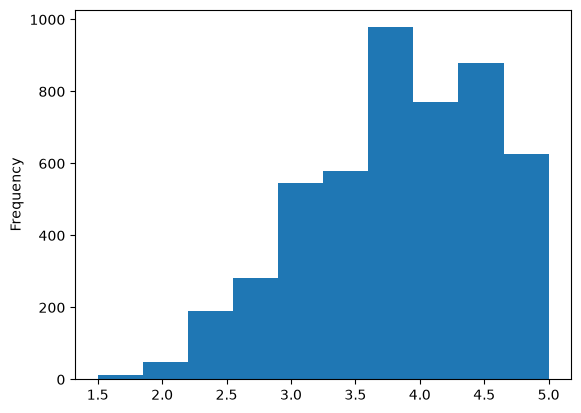

In [195]:
df['CSAT_Score'].plot(kind='hist')

In [196]:
df['CSAT_Score']=df['CSAT_Score'].fillna(df['CSAT_Score'].median())

<Axes: ylabel='Frequency'>

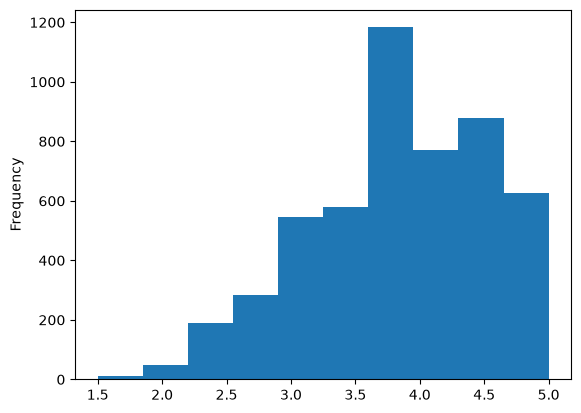

In [197]:
df['CSAT_Score'].plot(kind='hist')

In [198]:
df.isna().sum()[df.isna().sum() > 0]

NPS_Score               222
Score                   826
Resolution_Days         312
Currency                247
revenue_per_employee    228
dtype: int64

<Axes: ylabel='Frequency'>

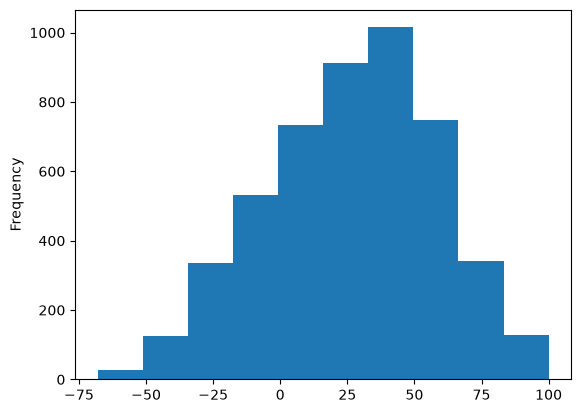

In [199]:
df['NPS_Score'].plot(kind='hist')

In [200]:
df['NPS_Score']=df['NPS_Score'].fillna(df['NPS_Score'].median())

<Axes: ylabel='Frequency'>

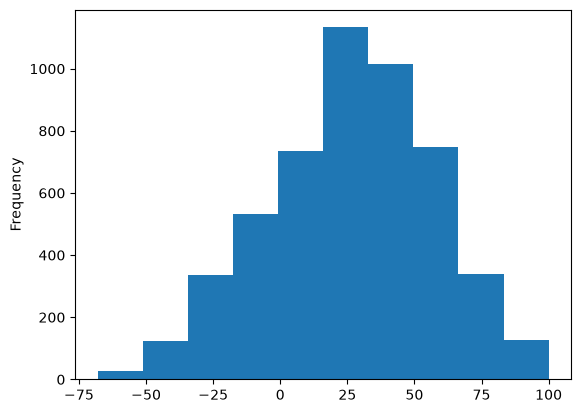

In [201]:
df['NPS_Score'].plot(kind='hist')

In [202]:
df.isna().sum()[df.isna().sum() > 0]

Score                   826
Resolution_Days         312
Currency                247
revenue_per_employee    228
dtype: int64

<Axes: ylabel='Frequency'>

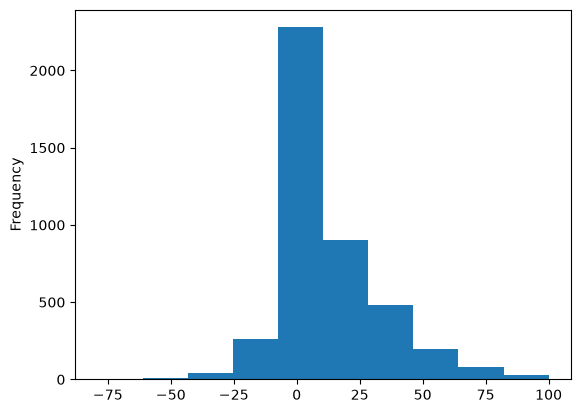

In [203]:
df['Score'].plot(kind='hist')

In [204]:
df['Score']=df['Score'].fillna(df['Score'].median())

<Axes: ylabel='Frequency'>

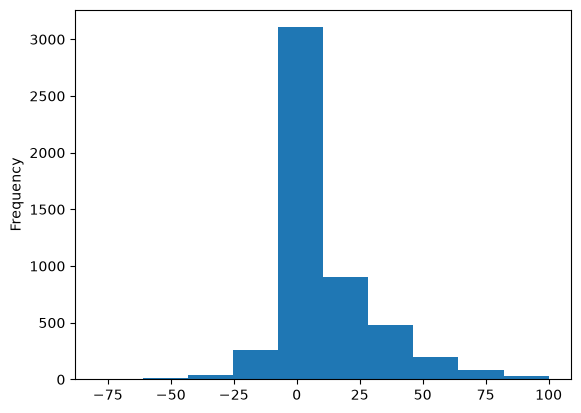

In [205]:
df['Score'].plot(kind='hist')

In [206]:
df.isna().sum()[df.isna().sum() > 0]

Resolution_Days         312
Currency                247
revenue_per_employee    228
dtype: int64

<Axes: ylabel='Frequency'>

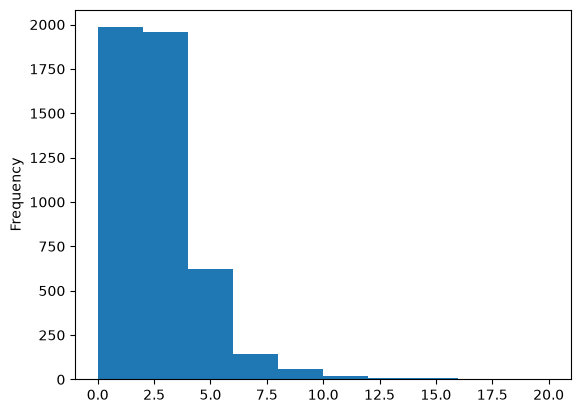

In [207]:
df['Resolution_Days'].plot(kind='hist')


In [208]:
df['Resolution_Days']=df['Resolution_Days'].fillna(df['Resolution_Days'].median())

<Axes: ylabel='Frequency'>

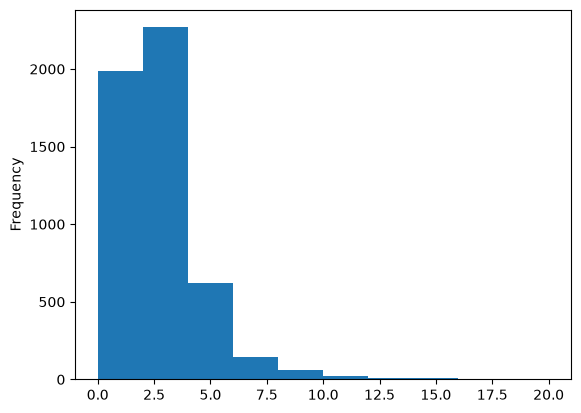

In [209]:
df['Resolution_Days'].plot(kind='hist')


In [210]:
df.isna().sum()[df.isna().sum() > 0]

Currency                247
revenue_per_employee    228
dtype: int64

In [211]:
country_currency_map = df.dropna(subset=['Currency']).drop_duplicates('Country')\
                        .set_index('Country')['Currency'].to_dict()

In [212]:
df['Currency'] = df['Currency'].fillna(df['Country'].map(country_currency_map))

In [213]:
df.isna().sum()[df.isna().sum() > 0]

revenue_per_employee    228
dtype: int64

In [214]:


df['revenue_per_employee'] = df['revenue_per_employee'].fillna(
    df['Lifetime_Revenue_USD'] / df['Employees'].replace(0, np.nan)
)

In [215]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

In [216]:
df.columns

Index(['Customer_ID', 'Geo_ID', 'Industry_ID', 'Product_ID', 'Cluster_Label',
       'Account_Tier', 'Company_Size', 'Company_Age_Years', 'Employees',
       'Legal_Entity_Type',
       ...
       'Base_Monthly_Price_USD', 'Included_Licenses', 'API_Limit_Monthly',
       'SLA_Uptime_Pct', 'Support_Level', 'AI_Features_Included',
       'avg_monthly_revenue', 'revenue_per_employee', 'licenses_unused',
       'Total_days'],
      dtype='str', length=107)

In [217]:
# df.drop(columns=['Customer_ID', 'Geo_ID', 'Industry_ID','Product_ID'], inplace=True)

In [218]:
df.to_csv(OUTPUT_DIR / 'cleaned_master_dataset.csv', index=False)